# 📊 EDA - Vietnam Agricultural Data Extraction Quality Analysis

## Mục tiêu
Phân tích chất lượng dữ liệu đã extract từ PDF báo cáo nông nghiệp (2009-2012) để:
1. Hiểu tổng quan về dataset
2. Phát hiện và định lượng các lỗi
3. Truy vết nguồn gốc lỗi (năm, tháng, phụ lục)
4. Chuẩn bị cho việc fix pipeline

## Các vấn đề đã biết
- ❌ Lỗi format trong `location_name` (có số thứ tự)
- ❌ Lỗi dữ liệu sai (month không khớp, giá trị bất thường)
- ❌ Trùng lặp `record_id` (thiếu `sub_item` trong hash key)

## 1. Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [3]:
# Define file paths
base_path = Path(r"D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm")

files = {
    2009: base_path / "2009" / "consolidated_2009.csv",
    2010: base_path / "2010" / "consolidated_2010.csv",
    2011: base_path / "2011" / "consolidated_2011.csv",
    2012: base_path / "2012" / "consolidated_2012.csv"
}

# Check if files exist
for year, path in files.items():
    if path.exists():
        print(f"✅ {year}: {path}")
    else:
        print(f"❌ {year}: File not found - {path}")

✅ 2009: D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\2009\consolidated_2009.csv
✅ 2010: D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\2010\consolidated_2010.csv
✅ 2011: D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\2011\consolidated_2011.csv
✅ 2012: D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\2012\consolidated_2012.csv


In [4]:
# Load all CSV files
dfs = {}
for year, path in files.items():
    if path.exists():
        df = pd.read_csv(path)
        dfs[year] = df
        print(f"📁 {year}: {len(df):,} rows, {len(df.columns)} columns")
    else:
        print(f"⚠️ Skipping {year} - file not found")

# Combine all years
df_all = pd.concat(dfs.values(), ignore_index=True)
print(f"\n📊 Total combined: {len(df_all):,} rows")

📁 2009: 9,863 rows, 14 columns
📁 2010: 10,972 rows, 13 columns
📁 2011: 9,768 rows, 13 columns
📁 2012: 9,667 rows, 13 columns

📊 Total combined: 40,270 rows


## 2. Basic Data Overview

In [5]:
# Display first few rows
print("=" * 100)
print("SAMPLE DATA")
print("=" * 100)
df_all.head(10)

SAMPLE DATA


,record_id,year,month,location_name,geo_level,sector,commodity,sub_item,attribute,value,unit,data_type,appendix_number,Unnamed: 13
0,8ba21a5a799a4683,2008,2,1. Gieo cấy lúa đông xuân cả nước,Provincial,Cultivation,Lúa,Đông Xuân,Area_Planted,21805,1000_ha,Actual,PL1,NaN
1,8d5b7a6f01861c79,2009,2,1. Gieo cấy lúa đông xuân cả nước,Provincial,Cultivation,Lúa,Đông Xuân,Area_Planted,27739,1000_ha,Actual,PL1,NaN
2,52470df47ed8406b,2008,2,- Vùng Duyên hải Bắc Trung bộ,Provincial,Cultivation,Unknown,NaN,Area_Planted,2705,1000_ha,Actual,PL1,NaN
3,ef2b0432c4f57b5c,2009,2,- Vùng Duyên hải Bắc Trung bộ,Provincial,Cultivation,Unknown,NaN,Area_Planted,3212,1000_ha,Actual,PL1,NaN
4,0b3c03bfd8e842b0,2008,2,+ Miền Nam,Provincial,Cultivation,Unknown,NaN,Area_Planted,17565,1000_ha,Actual,PL1,NaN
5,c9b1fc784c8c4a35,2009,2,+ Miền Nam,Provincial,Cultivation,Unknown,NaN,Area_Planted,18403,1000_ha,Actual,PL1,NaN
6,cdc5c3572c601d04,2008,2,2. Thu hoạch lúa đông xuân ở miền Nam,Provincial,Cultivation,Lúa,Đông Xuân,Area_Harvested,2567,1000_ha,Actual,PL1,NaN
7,877dd399acb5a7b9,2009,2,2. Thu hoạch lúa đông xuân ở miền Nam,Provincial,Cultivation,Lúa,Đông Xuân,Area_Harvested,2865,1000_ha,Actual,PL1,NaN
8,f633a96202b9eeb6,2008,2,3. Gieo trồng màu lương thực(),Provincial,Cultivation,Màu lương thực,NaN,Area_Planted,3980,1000_ha,Actual,PL1,NaN
9,ed16568e76eec4da,2009,2,3. Gieo trồng màu lương thực(),Provincial,Cultivation,Màu lương thực,NaN,Area_Planted,3685,1000_ha,Actual,PL1,NaN


In [6]:
# Data types and info
print("=" * 100)
print("DATA TYPES & INFO")
print("=" * 100)
df_all.info()

DATA TYPES & INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40270 entries, 0 to 40269
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   record_id        40270 non-null  object
 1   year             40270 non-null  int64 
 2   month            40270 non-null  int64 
 3   location_name    40270 non-null  object
 4   geo_level        40270 non-null  object
 5   sector           40270 non-null  object
 6   commodity        40270 non-null  object
 7   sub_item         3652 non-null   object
 8   attribute        40269 non-null  object
 9   value            40270 non-null  object
 10  unit             40270 non-null  object
 11  data_type        40270 non-null  object
 12  appendix_number  40270 non-null  object
 13  Unnamed: 13      1 non-null      object
dtypes: int64(2), object(12)
memory usage: 4.3+ MB


In [7]:
# Column names
print("=" * 100)
print("COLUMNS")
print("=" * 100)
for i, col in enumerate(df_all.columns, 1):
    print(f"{i:2d}. {col}")

COLUMNS
 1. record_id
 2. year
 3. month
 4. location_name
 5. geo_level
 6. sector
 7. commodity
 8. sub_item
 9. attribute
10. value
11. unit
12. data_type
13. appendix_number
14. Unnamed: 13


In [8]:
# Basic statistics
print("=" * 100)
print("BASIC STATISTICS")
print("=" * 100)
df_all.describe(include='all')

BASIC STATISTICS


,record_id,year,month,location_name,geo_level,sector,commodity,sub_item,attribute,value,unit,data_type,appendix_number,Unnamed: 13
count,40270,40270.000000,40270.000000,40270,40270,40270,40270,3652,40269,40270.0,40270,40270,40270,1
unique,16468,NaN,NaN,447,5,5,557,4,10,18084.0,11,5,34,1
top,01baf24094c9a631,NaN,NaN,Cả nước,Provincial,Cultivation,Lúa,Xuất khẩu,Area_Planted,1000.0,ha,Actual,PL4,PL1
freq,98,NaN,NaN,5942,32949,32960,23678,3136,32146,311.0,31718,36377,8118,1
mean,NaN,2010.466799,6.289123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,1.108743,3.378801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2008.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2010.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2010.000000,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2011.000000,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Distribution Analysis

RECORDS PER YEAR
year
2008      115
2009     9850
2010    10972
2011     9788
2012     9545
Name: count, dtype: int64

Total: 40,270


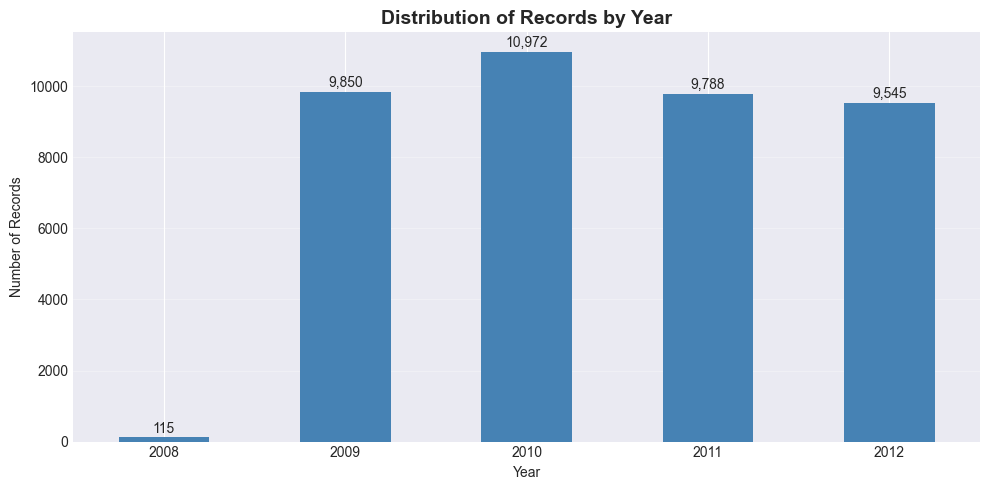

In [9]:
# Records per year
print("=" * 100)
print("RECORDS PER YEAR")
print("=" * 100)
year_dist = df_all['year'].value_counts().sort_index()
print(year_dist)
print(f"\nTotal: {year_dist.sum():,}")

# Visualization
plt.figure(figsize=(10, 5))
year_dist.plot(kind='bar', color='steelblue')
plt.title('Distribution of Records by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(year_dist.values):
    plt.text(i, v + 50, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

RECORDS PER MONTH
month
1     4192
2     2948
3     3290
4     3830
5     3233
6     2623
7     3757
8     3871
9     3809
10    3197
11    3676
12    1844
Name: count, dtype: int64


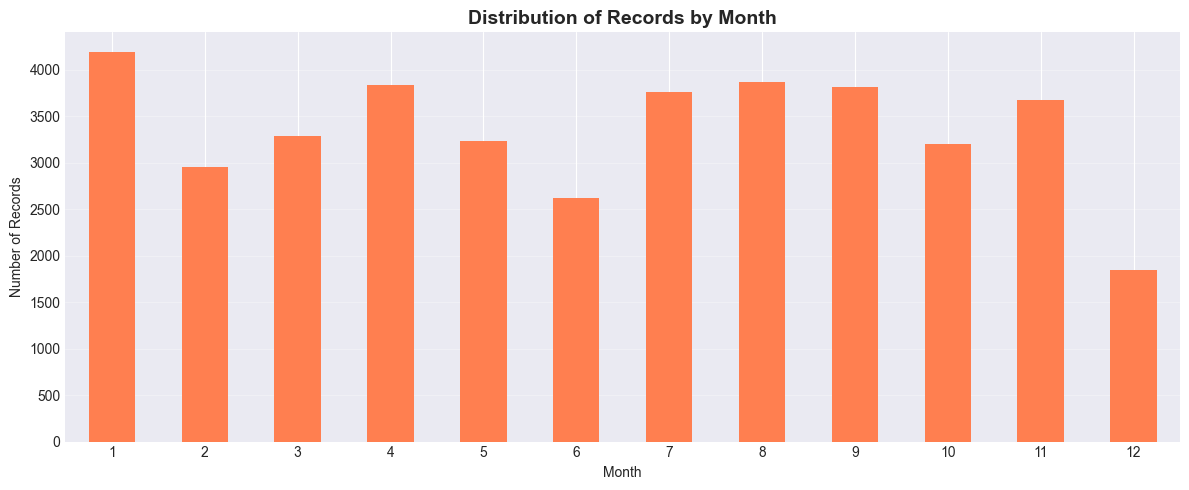

In [10]:
# Records per month
print("=" * 100)
print("RECORDS PER MONTH")
print("=" * 100)
month_dist = df_all['month'].value_counts().sort_index()
print(month_dist)

# Visualization
plt.figure(figsize=(12, 5))
month_dist.plot(kind='bar', color='coral')
plt.title('Distribution of Records by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Records per source (phụ lục)
print("=" * 100)
print("RECORDS PER SOURCE (PHỤ LỤC)")
print("=" * 100)
if 'source' in df_all.columns:
    source_dist = df_all['source'].value_counts()
    print(source_dist)
    
    # Visualization
    plt.figure(figsize=(14, 6))
    source_dist.head(20).plot(kind='barh', color='mediumseagreen')
    plt.title('Top 20 Sources (Phụ lục)', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Records')
    plt.ylabel('Source')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 'source' column not found")

RECORDS PER SOURCE (PHỤ LỤC)
⚠️ 'source' column not found


YEAR-MONTH DISTRIBUTION HEATMAP
month    1    2    3     4     5     6     7     8    9    10    11   12
year                                                                    
2008      0   10   13     9    13    14    11    14    9    9     7    6
2009   1029  685  743   708   971   989   843   935  978  834   889  246
2010   1185  758  731  1131  1308  1413   888   920  926  796   791  125
2011   1141  737  949  1062    13   136  1043  1050  979  767  1020  891
2012    837  758  854   920   928    71   972   952  917  791   969  576


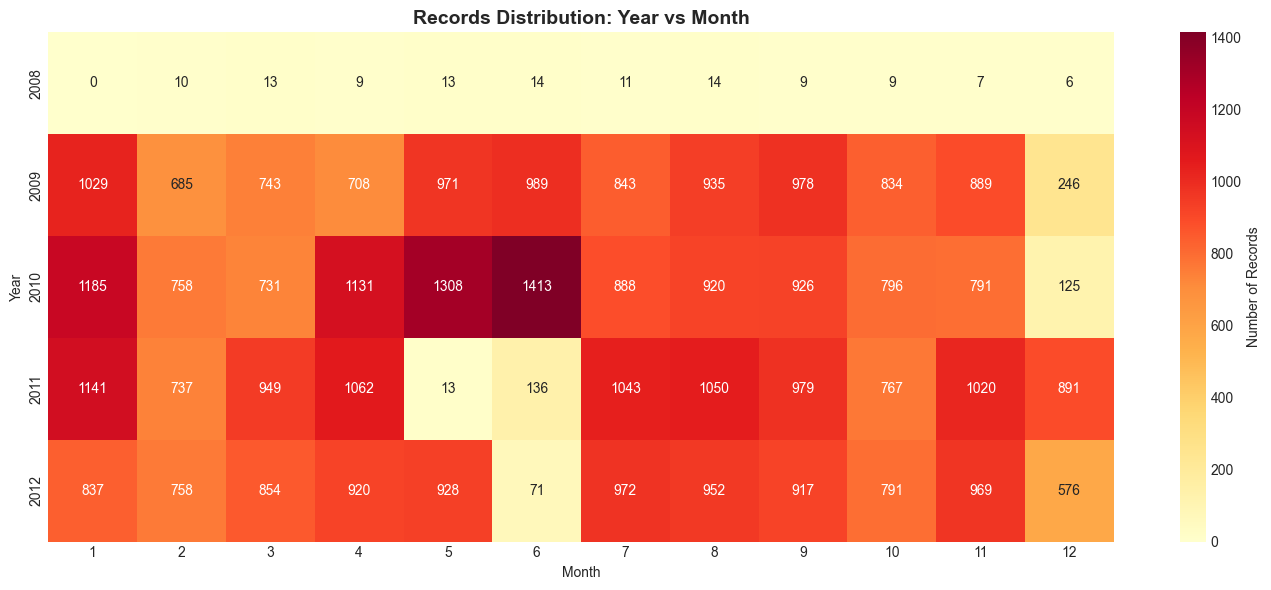

In [12]:
# Year-Month heatmap
print("=" * 100)
print("YEAR-MONTH DISTRIBUTION HEATMAP")
print("=" * 100)
year_month_pivot = df_all.groupby(['year', 'month']).size().unstack(fill_value=0)
print(year_month_pivot)

# Visualization
plt.figure(figsize=(14, 6))
sns.heatmap(year_month_pivot, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Number of Records'})
plt.title('Records Distribution: Year vs Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

## 4. Missing Values Analysis

MISSING VALUES ANALYSIS
         Column  Missing_Count  Missing_Percentage
13  Unnamed: 13          40269           99.997517
7      sub_item          36618           90.931214
8     attribute              1            0.002483


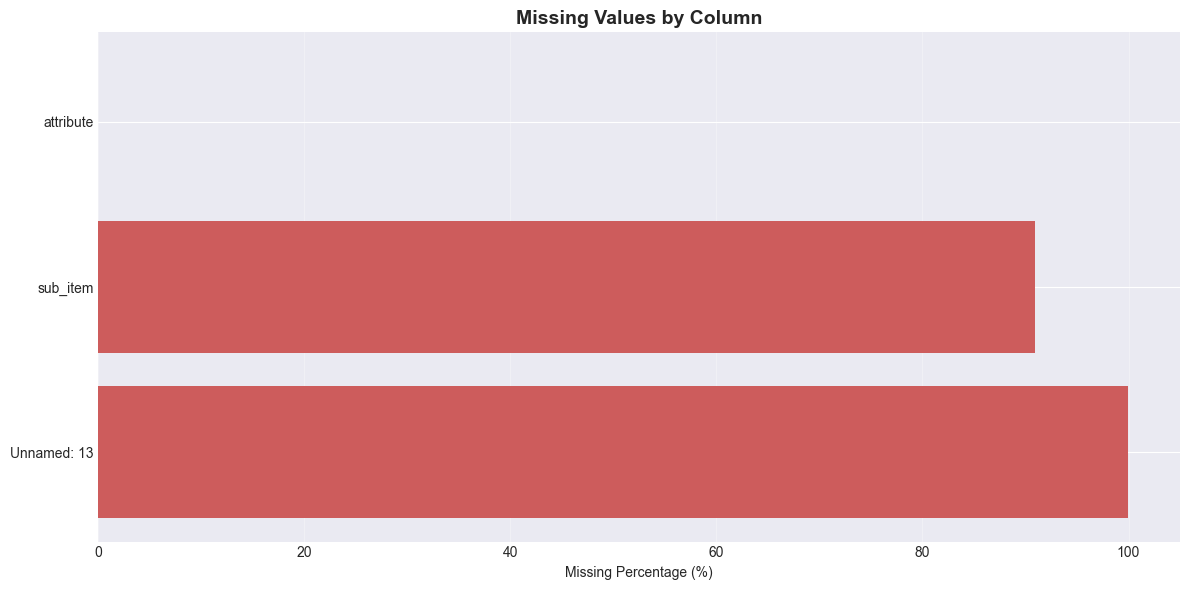

In [13]:
# Missing values count
print("=" * 100)
print("MISSING VALUES ANALYSIS")
print("=" * 100)
missing = df_all.isnull().sum()
missing_pct = (missing / len(df_all)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0])

# Visualization
if missing_df['Missing_Count'].sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_data = missing_df[missing_df['Missing_Count'] > 0]
    plt.barh(missing_data['Column'], missing_data['Missing_Percentage'], color='indianred')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No missing values found!")

## 5. Duplicate Record_ID Analysis

In [14]:
# Check for duplicate record_ids
print("=" * 100)
print("DUPLICATE RECORD_ID ANALYSIS")
print("=" * 100)

if 'record_id' in df_all.columns:
    total_records = len(df_all)
    unique_ids = df_all['record_id'].nunique()
    duplicates = total_records - unique_ids
    
    print(f"Total records: {total_records:,}")
    print(f"Unique record_ids: {unique_ids:,}")
    print(f"Duplicate count: {duplicates:,}")
    print(f"Duplicate percentage: {(duplicates/total_records)*100:.2f}%")
    
    if duplicates > 0:
        print("\n⚠️ DUPLICATE RECORD_IDs DETECTED!")
        
        # Find duplicated IDs
        dup_ids = df_all[df_all.duplicated(subset=['record_id'], keep=False)]
        dup_id_counts = dup_ids['record_id'].value_counts()
        
        print(f"\nNumber of record_ids with duplicates: {len(dup_id_counts):,}")
        print(f"\nTop 10 most duplicated record_ids:")
        print(dup_id_counts.head(10))
    else:
        print("\n✅ No duplicate record_ids found!")
else:
    print("⚠️ 'record_id' column not found")

DUPLICATE RECORD_ID ANALYSIS
Total records: 40,270
Unique record_ids: 16,468
Duplicate count: 23,802
Duplicate percentage: 59.11%

⚠️ DUPLICATE RECORD_IDs DETECTED!

Number of record_ids with duplicates: 4,428

Top 10 most duplicated record_ids:
record_id
01baf24094c9a631    98
3deb2f26d78219da    91
df09c0e39d986d6b    69
39a8fb1b8b9af9fc    68
9332c2ff6de3822e    44
be2f0692c3d9fe11    44
d446cc50180f328c    42
5108989879666245    42
e0d6a2547ba052d1    41
fb262b09f11874c2    38
Name: count, dtype: int64


In [15]:
# Sample duplicate records
if 'record_id' in df_all.columns and duplicates > 0:
    print("=" * 100)
    print("SAMPLE DUPLICATE RECORDS")
    print("=" * 100)
    
    # Get first duplicated ID
    first_dup_id = dup_id_counts.index[0]
    sample_dups = df_all[df_all['record_id'] == first_dup_id]
    
    print(f"\nShowing all records with record_id = {first_dup_id}:")
    print(f"Count: {len(sample_dups)}")
    display(sample_dups)

SAMPLE DUPLICATE RECORDS

Showing all records with record_id = 01baf24094c9a631:
Count: 98


,record_id,year,month,location_name,geo_level,sector,commodity,sub_item,attribute,value,unit,data_type,appendix_number,Unnamed: 13
11221,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,139.0,1000_ha,Estimated,PL6a,NaN
11223,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,50.0,1000_ha,Estimated,PL6a,NaN
11225,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,383.0,1000_ha,Estimated,PL6a,NaN
11227,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,10.0,1000_ha,Estimated,PL6a,NaN
11229,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,10.0,1000_ha,Estimated,PL6a,NaN
11231,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,9.0,1000_ha,Estimated,PL6a,NaN
11233,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,508.0,1000_ha,Estimated,PL6a,NaN
11235,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,208.0,1000_ha,Estimated,PL6a,NaN
11237,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,155.0,1000_ha,Estimated,PL6a,NaN
11239,01baf24094c9a631,2010,2,Cả nước,National,Forestry,Rừng,NaN,Area,60.0,1000_ha,Estimated,PL6a,NaN


In [16]:
# Analyze what makes duplicates different
if 'record_id' in df_all.columns and duplicates > 0:
    print("=" * 100)
    print("DUPLICATE ANALYSIS: WHAT'S DIFFERENT?")
    print("=" * 100)
    
    # Check which columns differ in duplicates
    sample_id = dup_id_counts.index[0]
    sample_group = df_all[df_all['record_id'] == sample_id]
    
    print("\nColumns that differ in duplicate records:")
    for col in df_all.columns:
        if sample_group[col].nunique() > 1:
            print(f"  - {col}: {sample_group[col].unique()}")

DUPLICATE ANALYSIS: WHAT'S DIFFERENT?

Columns that differ in duplicate records:
  - value: [139.0 50.0 383.0 10.0 9.0 508.0 208.0 155.0 60.0 28.0 57.0 198389.0
 26942.0 23537.0 11794.0 8852.0 7581.0 7425.0 7404.0 7264.0 6585.0 5049.0
 117885.0 82578.0 7143.0 4672.0 3602.0 3585.0 2996.0 2463.0 2026.0 1090.0
 1039.0 14548.0 2803.0 2242.0 1285.0 855.0 772.0 601.0 492.0 466.0 442.0
 393.0 204963.0 117804.0 26623.0 23827.0 6187.0 5345.0 2918.0 1730.0
 1438.0 980.0 51155.0 19077.0 10935.0 2870.0 285.0 126.0 67.0 48.0 32.0
 44863.0 12070.0 8391.0 5796.0 4650.0 2904.0 1988.0 1967.0 1304.0 1048.0
 911.0 66182.0 25156.0 20694.0 15446.0 2090.0 423.0 247.0 195.0 138.0
 113.0 97.0 33217.0 17244.0 15481.0 292.0 88343.0 14735.0 12852.0 12208.0
 10381.0 6372.0 6040.0 3340.0]
  - appendix_number: ['PL6a' 'PL6b' 'PL6c']


## 6. Location_Name Format Errors

In [17]:
# Find location_name with numbering prefix (e.g., "2. Thu hoạch...")
print("=" * 100)
print("LOCATION_NAME FORMAT ERRORS")
print("=" * 100)

if 'location_name' in df_all.columns:
    # Pattern: starts with number followed by dot
    pattern = r'^\d+\.\s'
    
    df_all['has_number_prefix'] = df_all['location_name'].astype(str).str.match(pattern)
    error_count = df_all['has_number_prefix'].sum()
    
    print(f"Total records with number prefix in location_name: {error_count:,}")
    print(f"Percentage: {(error_count/len(df_all))*100:.2f}%")
    
    if error_count > 0:
        print("\n⚠️ FORMAT ERRORS DETECTED!")
        
        # Show unique error patterns
        error_locations = df_all[df_all['has_number_prefix']]['location_name'].value_counts()
        print(f"\nUnique error patterns: {len(error_locations)}")
        print("\nTop 20 most common errors:")
        print(error_locations.head(20))
    else:
        print("\n✅ No number prefix errors found!")
else:
    print("⚠️ 'location_name' column not found")

LOCATION_NAME FORMAT ERRORS
Total records with number prefix in location_name: 267
Percentage: 0.66%

⚠️ FORMAT ERRORS DETECTED!

Unique error patterns: 48

Top 20 most common errors:
location_name
1. Gieo cấy lúa đông xuân cả nước            17
1. Thu hoạch lúa hè thu miền Nam             14
3. Gieo trồng màu lương thực()               12
2. Thu hoạch lúa đông xuân ở miền Nam        12
2. Thu hoạch lúa đông xuân miền Nam          12
5. Gieo trồng rau, đậu các loại()            12
2. Gieo cấy lúa mùa cả nước                  12
3. Gieo trồng cây vụ đông ở miền Bắc         12
1. Gieo cấy lúa hè thu miền Nam               8
4. Gieo trồng cây công nghiệp ngắn ngày()     8
2. Gieo cấy lúa mùa ở miền Nam                8
4. Gieo trồng cây vụ đông ở miền Bắc          8
1. Thu hoạch lúa hè thu ở miền Nam            8
3. Gieo cấy lúa đông xuân ở miền Nam          8
1. Thu hoạch lúa mùa ở miền Bắc               8
4. Gieo trồng rau, đậu các loại               8
2. Thu hoạch lúa mùa ở miền Nam   

In [18]:
# Sample records with location_name errors
if 'location_name' in df_all.columns and error_count > 0:
    print("=" * 100)
    print("SAMPLE LOCATION_NAME ERRORS")
    print("=" * 100)
    
    error_samples = df_all[df_all['has_number_prefix']].head(10)
    display(error_samples[['year', 'month', 'location_name']])

SAMPLE LOCATION_NAME ERRORS


,year,month,location_name
0,2008,2,1. Gieo cấy lúa đông xuân cả nước
1,2009,2,1. Gieo cấy lúa đông xuân cả nước
6,2008,2,2. Thu hoạch lúa đông xuân ở miền Nam
7,2009,2,2. Thu hoạch lúa đông xuân ở miền Nam
8,2008,2,3. Gieo trồng màu lương thực()
9,2009,2,3. Gieo trồng màu lương thực()
14,2008,2,4. Gieo trồng cây công nghiệp ngắn ngày(
15,2009,2,4. Gieo trồng cây công nghiệp ngắn ngày(
18,2008,2,"5. Gieo trồng rau, đậu các loại()"
19,2009,2,"5. Gieo trồng rau, đậu các loại()"


LOCATION_NAME ERRORS BY YEAR
      Total_Records  Error_Count  Error_Percentage
year                                              
2008            115           35             30.43
2009           9850           60              0.61
2010          10972           64              0.58
2011           9788           70              0.72
2012           9545           38              0.40


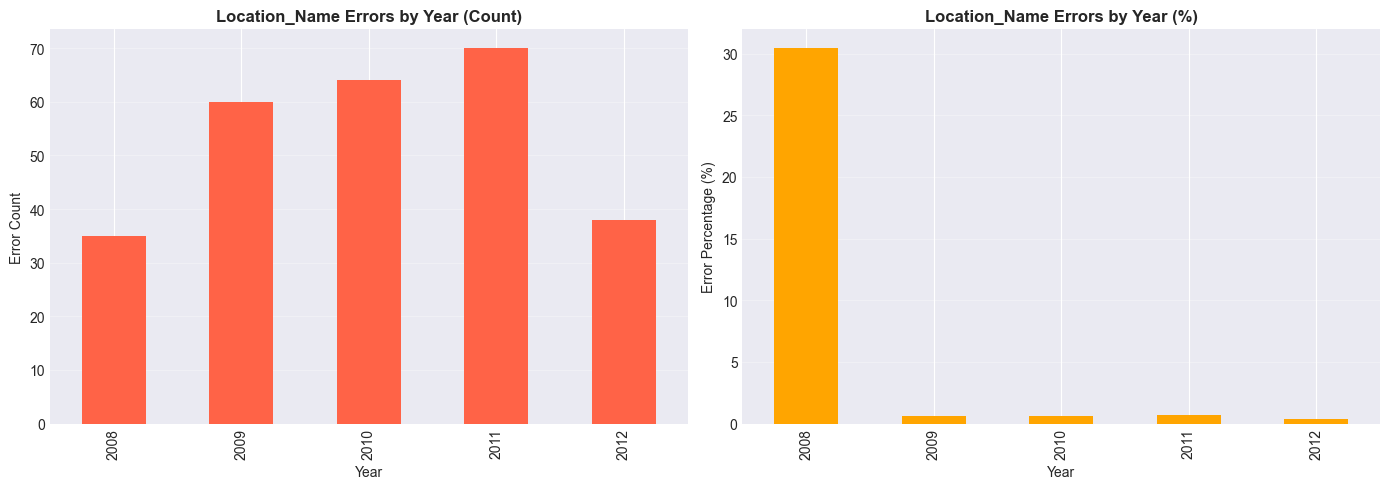

In [19]:
# Distribution of errors by year
if 'location_name' in df_all.columns and error_count > 0:
    print("=" * 100)
    print("LOCATION_NAME ERRORS BY YEAR")
    print("=" * 100)
    
    error_by_year = df_all[df_all['has_number_prefix']].groupby('year').size()
    total_by_year = df_all.groupby('year').size()
    error_pct_by_year = (error_by_year / total_by_year * 100).round(2)
    
    error_summary = pd.DataFrame({
        'Total_Records': total_by_year,
        'Error_Count': error_by_year,
        'Error_Percentage': error_pct_by_year
    })
    print(error_summary)
    
    # Visualization
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    error_by_year.plot(kind='bar', ax=ax[0], color='tomato')
    ax[0].set_title('Location_Name Errors by Year (Count)', fontweight='bold')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Error Count')
    ax[0].grid(axis='y', alpha=0.3)
    
    error_pct_by_year.plot(kind='bar', ax=ax[1], color='orange')
    ax[1].set_title('Location_Name Errors by Year (%)', fontweight='bold')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Error Percentage (%)')
    ax[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [20]:
# Distribution of errors by source (phụ lục)
if 'location_name' in df_all.columns and 'source' in df_all.columns and error_count > 0:
    print("=" * 100)
    print("LOCATION_NAME ERRORS BY SOURCE (PHỤ LỤC)")
    print("=" * 100)
    
    error_by_source = df_all[df_all['has_number_prefix']]['source'].value_counts()
    print("Top 20 sources with most errors:")
    print(error_by_source.head(20))
    
    # Visualization
    plt.figure(figsize=(12, 8))
    error_by_source.head(20).plot(kind='barh', color='crimson')
    plt.title('Top 20 Sources with Location_Name Errors', fontsize=14, fontweight='bold')
    plt.xlabel('Error Count')
    plt.ylabel('Source')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Other Data Quality Issues

In [21]:
# Check for unusual characters in text columns
print("=" * 100)
print("UNUSUAL CHARACTERS CHECK")
print("=" * 100)

text_columns = df_all.select_dtypes(include=['object']).columns

for col in text_columns:
    # Check for common issues
    has_newline = df_all[col].astype(str).str.contains('\n', na=False).sum()
    has_tab = df_all[col].astype(str).str.contains('\t', na=False).sum()
    has_multiple_spaces = df_all[col].astype(str).str.contains('\s{2,}', na=False).sum()
    
    if has_newline > 0 or has_tab > 0 or has_multiple_spaces > 0:
        print(f"\n{col}:")
        if has_newline > 0:
            print(f"  - Contains newline: {has_newline:,} records")
        if has_tab > 0:
            print(f"  - Contains tab: {has_tab:,} records")
        if has_multiple_spaces > 0:
            print(f"  - Contains multiple spaces: {has_multiple_spaces:,} records")

UNUSUAL CHARACTERS CHECK

location_name:
  - Contains multiple spaces: 184 records


In [22]:
# Check numeric columns for outliers
print("=" * 100)
print("NUMERIC OUTLIERS ANALYSIS")
print("=" * 100)

numeric_columns = df_all.select_dtypes(include=[np.number]).columns
print(f"Numeric columns: {list(numeric_columns)}\n")

for col in numeric_columns:
    if col not in ['year', 'month']:  # Skip year and month
        q1 = df_all[col].quantile(0.25)
        q3 = df_all[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers = df_all[(df_all[col] < lower_bound) | (df_all[col] > upper_bound)]
        
        if len(outliers) > 0:
            print(f"{col}:")
            print(f"  - Outliers: {len(outliers):,} ({len(outliers)/len(df_all)*100:.2f}%)")
            print(f"  - Range: [{df_all[col].min():.2f}, {df_all[col].max():.2f}]")
            print(f"  - IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
            print()

NUMERIC OUTLIERS ANALYSIS
Numeric columns: ['year', 'month']



## 8. Month Validation (Cross-check with source files)

In [23]:
# Extract month from source filename and compare with month column
print("=" * 100)
print("MONTH VALIDATION")
print("=" * 100)

if 'source' in df_all.columns:
    # Try to extract month from source filename
    # Pattern: looking for _t{month}_ or similar
    df_all['source_month'] = df_all['source'].astype(str).str.extract(r'_t(\d{2})_', expand=False)
    df_all['source_month'] = pd.to_numeric(df_all['source_month'], errors='coerce')
    
    # Compare
    df_all['month_mismatch'] = (df_all['month'] != df_all['source_month']) & df_all['source_month'].notna()
    
    mismatch_count = df_all['month_mismatch'].sum()
    print(f"Records with month mismatch: {mismatch_count:,}")
    
    if mismatch_count > 0:
        print("\n⚠️ MONTH MISMATCHES DETECTED!")
        
        # Show samples
        print("\nSample mismatches:")
        mismatches = df_all[df_all['month_mismatch']][['year', 'month', 'source_month', 'source']].head(20)
        display(mismatches)
    else:
        print("\n✅ No month mismatches found (or unable to extract month from source)")
else:
    print("⚠️ 'source' column not found")

MONTH VALIDATION
⚠️ 'source' column not found


## 9. Categorical Columns Analysis

In [24]:
# Analyze categorical columns
print("=" * 100)
print("CATEGORICAL COLUMNS ANALYSIS")
print("=" * 100)

categorical_cols = ['location_name', 'sector', 'commodity', 'sub_item', 'attribute', 'data_type', 'unit', 'value_type']

for col in categorical_cols:
    if col in df_all.columns:
        unique_count = df_all[col].nunique()
        print(f"\n{col}:")
        print(f"  - Unique values: {unique_count:,}")
        print(f"  - Top 10 values:")
        print(df_all[col].value_counts().head(10))
    else:
        print(f"\n{col}: ⚠️ Column not found")

CATEGORICAL COLUMNS ANALYSIS

location_name:
  - Unique values: 447
  - Top 10 values:
location_name
Cả nước         5942
Miền Nam         737
ĐBS Cửu Long     703
Đông Nam Bộ      694
Phú Yên          677
Tây Nguyên       638
Đồng Nai         609
An Giang         587
Vĩnh Long        574
Bình Thuận       567
Name: count, dtype: int64

sector:
  - Unique values: 5
  - Top 10 values:
sector
Cultivation    32960
Trade           3572
Investment      2207
Forestry        1530
Provincial         1
Name: count, dtype: int64

commodity:
  - Unique values: 557
  - Top 10 values:
commodity
Lúa           23678
Lạc            1788
Rừng           1413
Ngô            1393
Mía            1334
Đậu             905
Khoai lang      845
Sắn             829
Thuốc lá        709
Rau             579
Name: count, dtype: int64

sub_item:
  - Unique values: 4
  - Top 10 values:
sub_item
Xuất khẩu    3136
Nhập khẩu     436
Đông Xuân      79
Unknown         1
Name: count, dtype: int64

attribute:
  - Unique value

## 10. Error Summary Report

In [25]:
# Create comprehensive error summary
print("=" * 100)
print("📋 COMPREHENSIVE ERROR SUMMARY REPORT")
print("=" * 100)

total_records = len(df_all)

error_summary = {
    'Total Records': total_records,
    'Unique record_ids': df_all['record_id'].nunique() if 'record_id' in df_all.columns else 'N/A',
    'Duplicate record_ids': duplicates if 'record_id' in df_all.columns else 'N/A',
    'Location_name format errors': error_count if 'location_name' in df_all.columns else 'N/A',
    'Month mismatches': mismatch_count if 'source' in df_all.columns else 'N/A',
    'Missing values (any column)': df_all.isnull().any(axis=1).sum(),
}

print("\n📊 OVERALL STATISTICS:")
for key, value in error_summary.items():
    if isinstance(value, int):
        pct = (value / total_records * 100) if value != total_records else 100
        print(f"  {key}: {value:,} ({pct:.2f}%)")
    else:
        print(f"  {key}: {value}")

print("\n" + "=" * 100)

📋 COMPREHENSIVE ERROR SUMMARY REPORT

📊 OVERALL STATISTICS:
  Total Records: 40,270 (100.00%)
  Unique record_ids: 16,468 (40.89%)
  Duplicate record_ids: 23,802 (59.11%)
  Location_name format errors: 267
  Month mismatches: N/A
  Missing values (any column): 40270



## 11. Export Error Records for Manual Review

In [26]:
# Export problematic records
print("=" * 100)
print("EXPORTING ERROR RECORDS")
print("=" * 100)

output_dir = Path(r"D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\error_analysis")
output_dir.mkdir(exist_ok=True)

# 1. Duplicate record_ids
if 'record_id' in df_all.columns and duplicates > 0:
    dup_records = df_all[df_all.duplicated(subset=['record_id'], keep=False)].sort_values('record_id')
    dup_file = output_dir / "duplicate_record_ids.csv"
    dup_records.to_csv(dup_file, index=False, encoding='utf-8-sig')
    print(f"✅ Exported {len(dup_records):,} duplicate records to: {dup_file}")

# 2. Location_name format errors
if 'location_name' in df_all.columns and error_count > 0:
    location_errors = df_all[df_all['has_number_prefix']]
    location_file = output_dir / "location_name_errors.csv"
    location_errors.to_csv(location_file, index=False, encoding='utf-8-sig')
    print(f"✅ Exported {len(location_errors):,} location_name errors to: {location_file}")

# 3. Month mismatches
if 'source' in df_all.columns and mismatch_count > 0:
    month_errors = df_all[df_all['month_mismatch']]
    month_file = output_dir / "month_mismatches.csv"
    month_errors.to_csv(month_file, index=False, encoding='utf-8-sig')
    print(f"✅ Exported {len(month_errors):,} month mismatches to: {month_file}")

# 4. Records with missing values
missing_records = df_all[df_all.isnull().any(axis=1)]
if len(missing_records) > 0:
    missing_file = output_dir / "records_with_missing_values.csv"
    missing_records.to_csv(missing_file, index=False, encoding='utf-8-sig')
    print(f"✅ Exported {len(missing_records):,} records with missing values to: {missing_file}")

print(f"\n📁 All error files saved to: {output_dir}")

EXPORTING ERROR RECORDS
✅ Exported 28,230 duplicate records to: D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\error_analysis\duplicate_record_ids.csv
✅ Exported 267 location_name errors to: D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\error_analysis\location_name_errors.csv
✅ Exported 40,270 records with missing values to: D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\error_analysis\records_with_missing_values.csv

📁 All error files saved to: D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\error_analysis


## 12. Recommendations

In [27]:
print("=" * 100)
print("💡 RECOMMENDATIONS")
print("=" * 100)

recommendations = []

if 'record_id' in df_all.columns and duplicates > 0:
    recommendations.append(
        "1. FIX DUPLICATE RECORD_IDs:\n"
        "   - Update generate_record_id() function to include 'sub_item' in hash key\n"
        "   - Re-run extraction for all years to regenerate unique IDs"
    )

if 'location_name' in df_all.columns and error_count > 0:
    recommendations.append(
        "2. FIX LOCATION_NAME FORMAT ERRORS:\n"
        "   - Add post-processing step to remove number prefixes (e.g., '2. ')\n"
        "   - Pattern: re.sub(r'^\\d+\\.\\s*', '', location_name)\n"
        "   - Consider fixing in extraction script or as data cleaning step"
    )

if 'source' in df_all.columns and mismatch_count > 0:
    recommendations.append(
        "3. FIX MONTH MISMATCHES:\n"
        "   - Review extraction logic to ensure month is correctly parsed\n"
        "   - Validate month against source filename before saving\n"
        "   - Check if issue is in specific phụ lục or years"
    )

recommendations.append(
    "4. ADD DATA VALIDATION:\n"
    "   - Implement validation checks in extraction pipeline\n"
    "   - Validate data types, ranges, and formats before saving\n"
    "   - Log validation errors for manual review"
)

recommendations.append(
    "5. IMPROVE EXTRACTION QUALITY:\n"
    "   - Review LLM prompts for better extraction accuracy\n"
    "   - Add examples of correct format in prompts\n"
    "   - Consider few-shot learning with good examples"
)

for rec in recommendations:
    print(f"\n{rec}")

print("\n" + "=" * 100)

💡 RECOMMENDATIONS

1. FIX DUPLICATE RECORD_IDs:
   - Update generate_record_id() function to include 'sub_item' in hash key
   - Re-run extraction for all years to regenerate unique IDs

2. FIX LOCATION_NAME FORMAT ERRORS:
   - Add post-processing step to remove number prefixes (e.g., '2. ')
   - Pattern: re.sub(r'^\d+\.\s*', '', location_name)
   - Consider fixing in extraction script or as data cleaning step

4. ADD DATA VALIDATION:
   - Implement validation checks in extraction pipeline
   - Validate data types, ranges, and formats before saving
   - Log validation errors for manual review

5. IMPROVE EXTRACTION QUALITY:
   - Review LLM prompts for better extraction accuracy
   - Add examples of correct format in prompts
   - Consider few-shot learning with good examples



In [28]:
"""
DEEP DIVE: Location_Name Error Analysis
========================================

Phân tích chi tiết các lỗi trong cột location_name

Logic kiểm tra:
1. Số thứ tự ở đầu: Pattern ^\\d+\\.\\s (ví dụ: "1. Gieo cấy...")
2. Dấu ngoặc rỗng: Pattern \\(\\) (ví dụ: "Gieo trồng màu lương thực()")
3. Dấu ngoặc mở không đóng: Pattern \\([^)]*$ (ví dụ: "Cây công nghiệp(")
4. Số xuất hiện trong text: Pattern \\d+ không phải ở đầu
5. Khoảng trắng thừa: Leading/trailing spaces, multiple spaces
6. Ký tự đặc biệt lạ: Tab, newline, special unicode characters
"""

import pandas as pd
import re
from pathlib import Path

# Giả sử df_all đã được load từ các cell trước
# Nếu chưa có, uncomment dòng dưới:
# df_all = pd.concat([pd.read_csv(f) for f in files.values()], ignore_index=True)

print("=" * 100)
print("🔍 COMPREHENSIVE LOCATION_NAME ERROR DETECTION")
print("=" * 100)

if 'location_name' in df_all.columns:
    # Create error flags for different types
    df_all['error_number_prefix'] = df_all['location_name'].astype(str).str.match(r'^\d+\.\s')
    df_all['error_empty_parens'] = df_all['location_name'].astype(str).str.contains(r'\(\)', regex=True)
    df_all['error_unclosed_parens'] = df_all['location_name'].astype(str).str.contains(r'\([^)]*$', regex=True)
    df_all['error_has_numbers'] = df_all['location_name'].astype(str).str.contains(r'\d', regex=True)
    df_all['error_leading_space'] = df_all['location_name'].astype(str).str.match(r'^\s')
    df_all['error_trailing_space'] = df_all['location_name'].astype(str).str.match(r'.*\s$')
    df_all['error_multiple_spaces'] = df_all['location_name'].astype(str).str.contains(r'\s{2,}', regex=True)
    
    # Count each error type
    error_counts = {
        'Số thứ tự ở đầu (1., 2., ...)': df_all['error_number_prefix'].sum(),
        'Dấu ngoặc rỗng ()': df_all['error_empty_parens'].sum(),
        'Dấu ngoặc không đóng (': df_all['error_unclosed_parens'].sum(),
        'Có chứa số': df_all['error_has_numbers'].sum(),
        'Khoảng trắng đầu': df_all['error_leading_space'].sum(),
        'Khoảng trắng cuối': df_all['error_trailing_space'].sum(),
        'Nhiều khoảng trắng liên tiếp': df_all['error_multiple_spaces'].sum()
    }
    
    print("\n📊 ERROR TYPE BREAKDOWN:")
    print("-" * 100)
    for error_type, count in error_counts.items():
        pct = (count / len(df_all)) * 100
        print(f"{error_type:40s}: {count:6,} records ({pct:5.2f}%)")
    
    # Any error
    df_all['has_any_location_error'] = (
        df_all['error_number_prefix'] | 
        df_all['error_empty_parens'] | 
        df_all['error_unclosed_parens'] | 
        df_all['error_leading_space'] | 
        df_all['error_trailing_space'] | 
        df_all['error_multiple_spaces']
    )
    
    total_errors = df_all['has_any_location_error'].sum()
    print("-" * 100)
    print(f"{'TOTAL RECORDS WITH ANY ERROR':40s}: {total_errors:6,} records ({(total_errors/len(df_all))*100:5.2f}%)")
    print("=" * 100)
else:
    print("⚠️ 'location_name' column not found")


# ============================================================================
# SAMPLE ERRORS BY TYPE
# ============================================================================
print("\n" + "=" * 100)
print("📋 SAMPLE ERRORS BY TYPE")
print("=" * 100)

if 'location_name' in df_all.columns:
    # 1. Number prefix errors
    if df_all['error_number_prefix'].sum() > 0:
        print("\n1️⃣ SỐ THỨ TỰ Ở ĐẦU (Top 10):")
        print("-" * 100)
        samples = df_all[df_all['error_number_prefix']][['year', 'month', 'location_name', 'appendix_number']].head(10)
        for idx, row in samples.iterrows():
            print(f"  [{row['year']}-{row['month']:02d}] [{row['appendix_number']}] {row['location_name']}")
    
    # 2. Empty parentheses
    if df_all['error_empty_parens'].sum() > 0:
        print("\n2️⃣ DẤU NGOẶC RỖNG () (Top 10):")
        print("-" * 100)
        samples = df_all[df_all['error_empty_parens']][['year', 'month', 'location_name', 'appendix_number']].head(10)
        for idx, row in samples.iterrows():
            print(f"  [{row['year']}-{row['month']:02d}] [{row['appendix_number']}] {row['location_name']}")
    
    # 3. Unclosed parentheses
    if df_all['error_unclosed_parens'].sum() > 0:
        print("\n3️⃣ DẤU NGOẶC KHÔNG ĐÓNG ( (Top 10):")
        print("-" * 100)
        samples = df_all[df_all['error_unclosed_parens']][['year', 'month', 'location_name', 'appendix_number']].head(10)
        for idx, row in samples.iterrows():
            print(f"  [{row['year']}-{row['month']:02d}] [{row['appendix_number']}] {row['location_name']}")
    
    # 4. Multiple spaces
    if df_all['error_multiple_spaces'].sum() > 0:
        print("\n4️⃣ NHIỀU KHOẢNG TRẮNG LIÊN TIẾP (Top 10):")
        print("-" * 100)
        samples = df_all[df_all['error_multiple_spaces']][['year', 'month', 'location_name', 'appendix_number']].head(10)
        for idx, row in samples.iterrows():
            print(f"  [{row['year']}-{row['month']:02d}] [{row['appendix_number']}] '{row['location_name']}'")

print("\n" + "=" * 100)


# ============================================================================
# ERROR DISTRIBUTION ANALYSIS
# ============================================================================
print("\n" + "=" * 100)
print("📊 ERROR DISTRIBUTION ANALYSIS")
print("=" * 100)

if 'has_any_location_error' in df_all.columns and df_all['has_any_location_error'].sum() > 0:
    errors_df = df_all[df_all['has_any_location_error']]
    
    # By year
    print("\n📅 ERRORS BY YEAR:")
    print("-" * 100)
    error_by_year = errors_df.groupby('year').size()
    total_by_year = df_all.groupby('year').size()
    error_pct = (error_by_year / total_by_year * 100).round(2)
    
    for year in sorted(df_all['year'].unique()):
        err_count = error_by_year.get(year, 0)
        total = total_by_year.get(year, 0)
        pct = error_pct.get(year, 0)
        print(f"  {year}: {err_count:4,} / {total:6,} records ({pct:5.2f}%)")
    
    # By month
    print("\n📆 ERRORS BY MONTH:")
    print("-" * 100)
    error_by_month = errors_df.groupby('month').size().sort_index()
    total_by_month = df_all.groupby('month').size()
    
    for month in sorted(df_all['month'].unique()):
        err_count = error_by_month.get(month, 0)
        total = total_by_month.get(month, 0)
        pct = (err_count / total * 100) if total > 0 else 0
        print(f"  Month {month:2d}: {err_count:4,} / {total:6,} records ({pct:5.2f}%)")
    
    # By appendix
    print("\n📑 ERRORS BY APPENDIX (Top 20):")
    print("-" * 100)
    error_by_appendix = errors_df['appendix_number'].value_counts().head(20)
    
    for appendix, count in error_by_appendix.items():
        total = (df_all['appendix_number'] == appendix).sum()
        pct = (count / total * 100) if total > 0 else 0
        print(f"  {appendix:10s}: {count:4,} / {total:6,} records ({pct:5.2f}%)")

print("\n" + "=" * 100)


# ============================================================================
# ERROR HOTSPOTS
# ============================================================================
print("\n" + "=" * 100)
print("🎯 ERROR HOTSPOTS (Year-Month-Appendix combinations with most errors)")
print("=" * 100)

if 'has_any_location_error' in df_all.columns and df_all['has_any_location_error'].sum() > 0:
    errors_df = df_all[df_all['has_any_location_error']]
    
    # Group by year, month, appendix
    hotspots = errors_df.groupby(['year', 'month', 'appendix_number']).size().sort_values(ascending=False)
    
    print("\nTop 30 combinations with most errors:")
    print("-" * 100)
    print(f"{'Year':6s} {'Month':6s} {'Appendix':12s} {'Errors':8s} {'% of Total'}")
    print("-" * 100)
    
    for (year, month, appendix), count in hotspots.head(30).items():
        # Get total records for this combination
        total = len(df_all[(df_all['year'] == year) & 
                           (df_all['month'] == month) & 
                           (df_all['appendix_number'] == appendix)])
        pct = (count / total * 100) if total > 0 else 0
        print(f"{year:6d} {month:6d} {appendix:12s} {count:8,} {pct:6.2f}%")
    
    print("\n" + "=" * 100)
    print("💡 TIP: Focus on fixing these hotspots first for maximum impact!")
    print("=" * 100)


# ============================================================================
# EXPORT DETAILED ERROR REPORT
# ============================================================================
print("\n" + "=" * 100)
print("💾 EXPORTING DETAILED LOCATION_NAME ERROR REPORT")
print("=" * 100)

if 'has_any_location_error' in df_all.columns and df_all['has_any_location_error'].sum() > 0:
    output_dir = Path(r"D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm\error_analysis")
    output_dir.mkdir(exist_ok=True)
    
    # Export all location_name errors with error type flags
    error_columns = [
        'year', 'month', 'appendix_number', 'location_name', 'sector', 'commodity',
        'error_number_prefix', 'error_empty_parens', 'error_unclosed_parens',
        'error_leading_space', 'error_trailing_space', 'error_multiple_spaces'
    ]
    
    errors_export = df_all[df_all['has_any_location_error']][error_columns]
    error_file = output_dir / "location_name_errors_detailed.csv"
    errors_export.to_csv(error_file, index=False, encoding='utf-8-sig')
    
    print(f"✅ Exported {len(errors_export):,} error records to:")
    print(f"   {error_file}")
    
    # Export summary by error type
    summary_data = []
    for error_col in ['error_number_prefix', 'error_empty_parens', 'error_unclosed_parens',
                      'error_leading_space', 'error_trailing_space', 'error_multiple_spaces']:
        error_type = error_col.replace('error_', '').replace('_', ' ').title()
        count = df_all[error_col].sum()
        pct = (count / len(df_all)) * 100
        summary_data.append({
            'Error_Type': error_type,
            'Count': count,
            'Percentage': round(pct, 2)
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_file = output_dir / "location_name_error_summary.csv"
    summary_df.to_csv(summary_file, index=False, encoding='utf-8-sig')
    
    print(f"✅ Exported error summary to:")
    print(f"   {summary_file}")
    
    print("\n" + "=" * 100)
else:
    print("No location_name errors found to export.")


🔍 COMPREHENSIVE LOCATION_NAME ERROR DETECTION

📊 ERROR TYPE BREAKDOWN:
----------------------------------------------------------------------------------------------------
Số thứ tự ở đầu (1., 2., ...)           :    267 records ( 0.66%)
Dấu ngoặc rỗng ()                       :     40 records ( 0.10%)
Dấu ngoặc không đóng (                  :      2 records ( 0.00%)
Có chứa số                              :  1,192 records ( 2.96%)
Khoảng trắng đầu                        :      0 records ( 0.00%)
Khoảng trắng cuối                       :      1 records ( 0.00%)
Nhiều khoảng trắng liên tiếp            :    184 records ( 0.46%)
----------------------------------------------------------------------------------------------------
TOTAL RECORDS WITH ANY ERROR            :    448 records ( 1.11%)

📋 SAMPLE ERRORS BY TYPE

1️⃣ SỐ THỨ TỰ Ở ĐẦU (Top 10):
----------------------------------------------------------------------------------------------------
  [2008-02] [PL1] 1. Gieo cấy lúa đông xuâ

In [32]:
"""
COMPREHENSIVE LOCATION_NAME ERROR ANALYSIS
==========================================

Phân tích toàn diện các lỗi trong location_name dựa trên patterns thực tế
Tạo báo cáo chi tiết để trace lỗi về năm-tháng-phụ lục

Author: Data Quality Team
Date: 2026-01-25
"""

import pandas as pd
import numpy as np
import re
from pathlib import Path
from collections import defaultdict

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_PATH = Path(r"D:\UIT\aThacSy\Data Mining\2. Data Pre-processing\vn_agri_dts\dataset\extract_llm")
OUTPUT_DIR = BASE_PATH / "error_analysis" / "location_name_error_analysis"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load consolidated data
print("=" * 100)
print("📂 LOADING DATA")
print("=" * 100)

files = {
    2009: BASE_PATH / "2009" / "consolidated_2009.csv",
    2010: BASE_PATH / "2010" / "consolidated_2010.csv",
    2011: BASE_PATH / "2011" / "consolidated_2011.csv",
    2012: BASE_PATH / "2012" / "consolidated_2012.csv"
}

dfs = {}
for year, path in files.items():
    if path.exists():
        df = pd.read_csv(path)
        dfs[year] = df
        print(f"✅ {year}: {len(df):,} rows")
    else:
        print(f"❌ {year}: File not found")

df_all = pd.concat(dfs.values(), ignore_index=True)
print(f"\n📊 Total: {len(df_all):,} rows")
print("=" * 100)


# ============================================================================
# ERROR DETECTION PATTERNS
# ============================================================================
print("\n" + "=" * 100)
print("🔍 DEFINING ERROR DETECTION PATTERNS")
print("=" * 100)

ERROR_PATTERNS = {
    # Category 1: Số thứ tự và ký hiệu đầu dòng
    'number_prefix': {
        'pattern': r'^\d+\.\s',
        'description': 'Số thứ tự ở đầu (1., 2., 3., ...)',
        'example': '1. Gieo cấy lúa đông xuân cả nước'
    },
    'plus_prefix': {
        'pattern': r'^\+\s',
        'description': 'Dấu + ở đầu',
        'example': '+ bắc trung bộ'
    },
    'minus_prefix': {
        'pattern': r'^-\s',
        'description': 'Dấu - ở đầu',
        'example': '- miền nam'
    },
    'bullet_prefix': {
        'pattern': r'^‐\s',
        'description': 'Dấu bullet (‐) ở đầu',
        'example': '‐ khoai lang'
    },
    
    # Category 2: Số dính vào text
    # Category 2: Số dính vào text
    'number_suffix': {
        'pattern': r'[a-zàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ]+\d+\.?\d*$',
        'description': 'Số dính vào cuối text',
        'example': ['miền nam1,926.2', 'lạc172.2']
    },
    'number_in_middle': {
        'pattern': r'\d+\.?\d*[a-zàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ]+',
        'description': 'Số ở giữa text',
        'example': ['1000ha', '2=3+7']
    },

    # Category 3: Dấu ngoặc
    'empty_parens': {
        'pattern': r'\(\)',
        'description': 'Dấu ngoặc rỗng ()',
        'example': 'Gieo trồng màu lương thực()'
    },
    'unclosed_parens': {
        'pattern': r'\([^)]*$',
        'description': 'Dấu ngoặc không đóng',
        'example': 'Cây công nghiệp ngắn ngày('
    },
    
    # Category 4: Khoảng trắng
    'leading_space': {
        'pattern': r'^\s+',
        'description': 'Khoảng trắng đầu',
        'example': ' Cả nước'
    },
    'trailing_space': {
        'pattern': r'\s+$',
        'description': 'Khoảng trắng cuối',
        'example': 'Cả nước '
    },
    'multiple_spaces': {
        'pattern': r'\s{2,}',
        'description': 'Nhiều khoảng trắng liên tiếp',
        'example': 'Cả  nước'
    },
    'space_in_word': {
        'pattern': r'[a-zàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ]+\s[a-zàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ]+(?=[a-zàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ])',
        'description': 'Khoảng trắng trong từ',
        'example': ['mi ền nam', 'đ ậu tương']
    },
    
    # Category 5: Nhiều location ghép lại (không có dấu phân cách)
    'concatenated_locations': {
        'pattern': r'[a-zàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ]{50,}',
        'description': 'Text quá dài (nhiều location ghép lại)',
        'example': 'phi lip pinxinh ga pocubađài loanmalaixia...'
    },
    
    # Category 6: Ký tự lạ / encoding issues
    'special_chars': {
        'pattern': r'[®©™æœ¬̧̃±×÷§¶†‡•‰′″‴※‼⁇⁈⁉]',
        'description': 'Ký tự đặc biệt lạ (encoding issues)',
        'example': 'tæng sè tr©u'
    },
    'unicode_issues': {
        'pattern': r'[ằẳẵặắằẳẵặ]{2,}',
        'description': 'Unicode bị lỗi (dấu trùng)',
        'example': 'cbằ ao ng'
    },
    
    # Category 7: Chỉ là số (không phải location)
    'only_numbers': {
        'pattern': r'^\d+\.?\d*$',
        'description': 'Chỉ toàn số (không phải location)',
        'example': ['125869.3', '14.585']
    },
    
    # Category 8: Chỉ là ký tự đơn
    'single_char': {
        'pattern': r'^[ivxIVX]+$',
        'description': 'Chỉ là chữ số La Mã hoặc ký tự đơn',
        'example': ['i', 'ii', 'iii', 'iv', 'v']
    },
    
    # Category 9: Typo / viết sai
    'typo_spacing': {
        'pattern': r'[a-zàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ][A-ZÀÁẢÃẠĂẮẰẲẴẶÂẤẦẨẪẬÈÉẺẼẸÊẾỀỂỄỆÌÍỈĨỊÒÓỎÕỌÔỐỒỔỖỘƠỚỜỞỠỢÙÚỦŨỤƯỨỪỬỮỰỲÝỶỸỴĐ]',
        'description': 'Không có khoảng trắng giữa từ (viết liền)',
        'example': ['miềnnam', 'ngắnngày', 'trungbộ']
    },
    
    # Category 10: Chứa metadata (không phải location)
    'contains_metadata': {
        'pattern': r'(diện tích|năng suất|sản lượng|dt gieo|dt cho|1000\s*ha|tạ/ha)',
        'description': 'Chứa metadata (header/column names)',
        'example': ['diện tích', 'dt gieo trồng', 'năng suất']
    },
    
    # Category 11: Chứa nhiều location (danh sách)
    'location_list': {
        'pattern': r'([a-zàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ\s]+\s){5,}',
        'description': 'Danh sách nhiều location',
        'example': 'hoa kỳ nhật bản trung quốc anh hàn quốc đức'
    }
}

print(f"✅ Defined {len(ERROR_PATTERNS)} error patterns")
for key, info in ERROR_PATTERNS.items():
    print(f"  - {key:25s}: {info['description']}")
print("=" * 100)


# ============================================================================
# DETECT ERRORS
# ============================================================================
print("\n" + "=" * 100)
print("🔍 DETECTING ERRORS IN LOCATION_NAME")
print("=" * 100)

if 'location_name' not in df_all.columns:
    print("❌ ERROR: 'location_name' column not found!")
    exit(1)

# Create error flags
for error_type, info in ERROR_PATTERNS.items():
    col_name = f'error_{error_type}'
    df_all[col_name] = df_all['location_name'].astype(str).str.contains(
        info['pattern'], 
        regex=True, 
        case=False,
        na=False
    )
    count = df_all[col_name].sum()
    pct = (count / len(df_all)) * 100
    print(f"{info['description']:50s}: {count:6,} ({pct:5.2f}%)")

# Create combined error flag
error_cols = [f'error_{key}' for key in ERROR_PATTERNS.keys()]
df_all['has_any_error'] = df_all[error_cols].any(axis=1)

total_errors = df_all['has_any_error'].sum()
print("-" * 100)
print(f"{'TOTAL RECORDS WITH ANY ERROR':50s}: {total_errors:6,} ({(total_errors/len(df_all))*100:5.2f}%)")
print("=" * 100)


# ============================================================================
# ERROR SUMMARY BY TYPE
# ============================================================================
print("\n" + "=" * 100)
print("📊 ERROR SUMMARY BY TYPE")
print("=" * 100)

error_summary = []
for error_type, info in ERROR_PATTERNS.items():
    col_name = f'error_{error_type}'
    count = df_all[col_name].sum()
    pct = (count / len(df_all)) * 100
    
    # Get sample
    samples = df_all[df_all[col_name]]['location_name'].unique()[:3]
    
    error_summary.append({
        'Error_Type': error_type,
        'Description': info['description'],
        'Count': count,
        'Percentage': round(pct, 2),
        'Sample_1': samples[0] if len(samples) > 0 else '',
        'Sample_2': samples[1] if len(samples) > 1 else '',
        'Sample_3': samples[2] if len(samples) > 2 else ''
    })

df_error_summary = pd.DataFrame(error_summary).sort_values('Count', ascending=False)
print(df_error_summary[['Error_Type', 'Description', 'Count', 'Percentage']].to_string(index=False))


# ============================================================================
# ERROR DISTRIBUTION BY YEAR-MONTH-APPENDIX
# ============================================================================
print("\n" + "=" * 100)
print("📍 ERROR DISTRIBUTION BY YEAR-MONTH-APPENDIX")
print("=" * 100)

errors_df = df_all[df_all['has_any_error']].copy()

# Group by year, month, appendix
error_distribution = errors_df.groupby(['year', 'month', 'appendix_number']).agg({
    'location_name': 'count',
    **{f'error_{key}': 'sum' for key in ERROR_PATTERNS.keys()}
}).reset_index()

error_distribution.rename(columns={'location_name': 'total_errors'}, inplace=True)

# Sort by total errors
error_distribution = error_distribution.sort_values('total_errors', ascending=False)

print(f"\nTop 30 Year-Month-Appendix combinations with most errors:")
print("-" * 100)
print(error_distribution.head(30).to_string(index=False))


# ============================================================================
# DETAILED ERROR RECORDS
# ============================================================================
print("\n" + "=" * 100)
print("📋 CREATING DETAILED ERROR REPORT")
print("=" * 100)

# Create detailed error report
error_records = errors_df[[
    'year', 'month', 'appendix_number', 'location_name', 
    'sector', 'commodity', 'sub_item', 'attribute', 'value'
] + error_cols].copy()

# Add error type summary column
def get_error_types(row):
    errors = []
    for error_type in ERROR_PATTERNS.keys():
        if row[f'error_{error_type}']:
            errors.append(error_type)
    return ', '.join(errors)

error_records['error_types'] = error_records.apply(get_error_types, axis=1)

# Sort by year, month, appendix
error_records = error_records.sort_values(['year', 'month', 'appendix_number', 'location_name'])

print(f"✅ Created detailed error report with {len(error_records):,} records")


# ============================================================================
# ERROR HOTSPOTS (Most problematic combinations)
# ============================================================================
print("\n" + "=" * 100)
print("🎯 ERROR HOTSPOTS ANALYSIS")
print("=" * 100)

# Find which year-month-appendix has highest error rate
hotspots = []
for (year, month, appendix), group in df_all.groupby(['year', 'month', 'appendix_number']):
    total = len(group)
    errors = group['has_any_error'].sum()
    error_rate = (errors / total * 100) if total > 0 else 0
    
    if errors > 0:
        # Count each error type
        error_breakdown = {}
        for error_type in ERROR_PATTERNS.keys():
            error_breakdown[error_type] = group[f'error_{error_type}'].sum()
        
        # Find most common error type
        most_common_error = max(error_breakdown.items(), key=lambda x: x[1])
        
        hotspots.append({
            'Year': year,
            'Month': month,
            'Appendix': appendix,
            'Total_Records': total,
            'Error_Records': errors,
            'Error_Rate_%': round(error_rate, 2),
            'Most_Common_Error': most_common_error[0],
            'Most_Common_Count': most_common_error[1]
        })

df_hotspots = pd.DataFrame(hotspots).sort_values('Error_Rate_%', ascending=False)

print("\nTop 30 hotspots (highest error rate):")
print("-" * 100)
print(df_hotspots.head(30).to_string(index=False))


# ============================================================================
# EXPORT RESULTS
# ============================================================================
print("\n" + "=" * 100)
print("💾 EXPORTING RESULTS")
print("=" * 100)

# 1. Error summary by type
summary_file = OUTPUT_DIR / "error_summary_by_type.csv"
df_error_summary.to_csv(summary_file, index=False, encoding='utf-8-sig')
print(f"✅ Exported error summary: {summary_file}")

# 2. Error distribution by year-month-appendix
distribution_file = OUTPUT_DIR / "error_distribution_by_source.csv"
error_distribution.to_csv(distribution_file, index=False, encoding='utf-8-sig')
print(f"✅ Exported error distribution: {distribution_file}")

# 3. Detailed error records
detailed_file = OUTPUT_DIR / "error_records_detailed.csv"
error_records.to_csv(detailed_file, index=False, encoding='utf-8-sig')
print(f"✅ Exported detailed error records: {detailed_file}")

# 4. Error hotspots
hotspots_file = OUTPUT_DIR / "error_hotspots.csv"
df_hotspots.to_csv(hotspots_file, index=False, encoding='utf-8-sig')
print(f"✅ Exported error hotspots: {hotspots_file}")

# 5. Unique error locations (for manual review)
unique_errors = errors_df['location_name'].unique()
unique_file = OUTPUT_DIR / "unique_error_locations.txt"
with open(unique_file, 'w', encoding='utf-8') as f:
    for i, loc in enumerate(sorted(unique_errors), 1):
        f.write(f"{i:4d}. {loc}\n")
print(f"✅ Exported unique error locations: {unique_file}")


# ============================================================================
# FINAL SUMMARY TABLE
# ============================================================================
print("\n" + "=" * 100)
print("📊 FINAL SUMMARY TABLE")
print("=" * 100)

summary_table = df_hotspots.head(20)[['Year', 'Month', 'Appendix', 'Error_Records', 'Error_Rate_%', 'Most_Common_Error']]
print("\nTop 20 sources to fix (prioritized by error rate):")
print("-" * 100)
print(summary_table.to_string(index=False))

print("\n" + "=" * 100)
print("✅ ANALYSIS COMPLETE!")
print("=" * 100)
print(f"\n📁 All results saved to: {OUTPUT_DIR}")
print("\n🎯 NEXT STEPS:")
print("  1. Review error_hotspots.csv to prioritize fixes")
print("  2. Check error_summary_by_type.csv to understand error patterns")
print("  3. Use error_records_detailed.csv to trace specific errors")
print("  4. Fix extraction logic for top hotspots first")
print("=" * 100)


📂 LOADING DATA
✅ 2009: 9,863 rows
✅ 2010: 10,972 rows
✅ 2011: 9,768 rows
✅ 2012: 9,667 rows

📊 Total: 40,270 rows

🔍 DEFINING ERROR DETECTION PATTERNS
✅ Defined 20 error patterns
  - number_prefix            : Số thứ tự ở đầu (1., 2., 3., ...)
  - plus_prefix              : Dấu + ở đầu
  - minus_prefix             : Dấu - ở đầu
  - bullet_prefix            : Dấu bullet (‐) ở đầu
  - number_suffix            : Số dính vào cuối text
  - number_in_middle         : Số ở giữa text
  - empty_parens             : Dấu ngoặc rỗng ()
  - unclosed_parens          : Dấu ngoặc không đóng
  - leading_space            : Khoảng trắng đầu
  - trailing_space           : Khoảng trắng cuối
  - multiple_spaces          : Nhiều khoảng trắng liên tiếp
  - space_in_word            : Khoảng trắng trong từ
  - concatenated_locations   : Text quá dài (nhiều location ghép lại)
  - special_chars            : Ký tự đặc biệt lạ (encoding issues)
  - unicode_issues           : Unicode bị lỗi (dấu trùng)
  - only_numb